# Gaussian Mixture Models & EM Algorithm

---

**Structure**
1. Introduction
2. The Math
3. Problem Class
4. Implementation — synthetic mixture dataset
5. Results
6. Limitations

## 1. Introduction

A **Gaussian Mixture Model (GMM)** is a probabilistic model that assumes data was generated from a weighted combination of K Gaussian distributions. Unlike K-Means which gives each point a hard cluster assignment, GMM gives every point a **probability of belonging to each cluster** — called a soft assignment.

**Intuition:** imagine height data for a population that mixes men and women. Neither group alone is Gaussian, but the combined distribution looks like two overlapping bells. A GMM fits both bells simultaneously and tells you: for any given height, here is the probability this person is from each group.

**The EM Algorithm** (Expectation-Maximisation) trains the GMM by alternating between two steps:
- **E-step (Expectation)**: given current parameters, compute the probability that each point belongs to each Gaussian (soft counts)
- **M-step (Maximisation)**: given those soft assignments, update the Gaussian parameters to maximise the likelihood

Each iteration is guaranteed to increase the log-likelihood until convergence.

## 2. The Math

### Mixture model
$$P(x|\theta) = \sum_{j=1}^{K} p_j \cdot \mathcal{N}(x;\mu^{(j)}, \sigma^{2(j)})$$

where $p_j$ are mixture weights ($\sum_j p_j = 1$).

### E-Step — soft assignments
$$p(j|i) = \frac{p_j \, \mathcal{N}(x^{(i)};\mu^{(j)}, \sigma^{2(j)})}{\sum_{j'} p_{j'} \, \mathcal{N}(x^{(i)};\mu^{(j')}, \sigma^{2(j')})}$$

### M-Step — parameter updates
$$\hat{n}_j = \sum_{i=1}^{n} p(j|i), \qquad \hat{p}_j = \frac{\hat{n}_j}{n}$$

$$\hat{\mu}^{(j)} = \frac{1}{\hat{n}_j}\sum_{i=1}^{n} p(j|i) \cdot x^{(i)}$$

$$\hat{\sigma}^{2(j)} = \frac{1}{\hat{n}_j}\sum_{i=1}^{n} p(j|i) \cdot \|x^{(i)} - \hat{\mu}^{(j)}\|^2$$

### Log-likelihood (monitored for convergence)
$$\ell(\theta) = \sum_{i=1}^{n} \log \sum_{j=1}^{K} p_j \, \mathcal{N}(x^{(i)};\mu^{(j)}, \sigma^{2(j)})$$

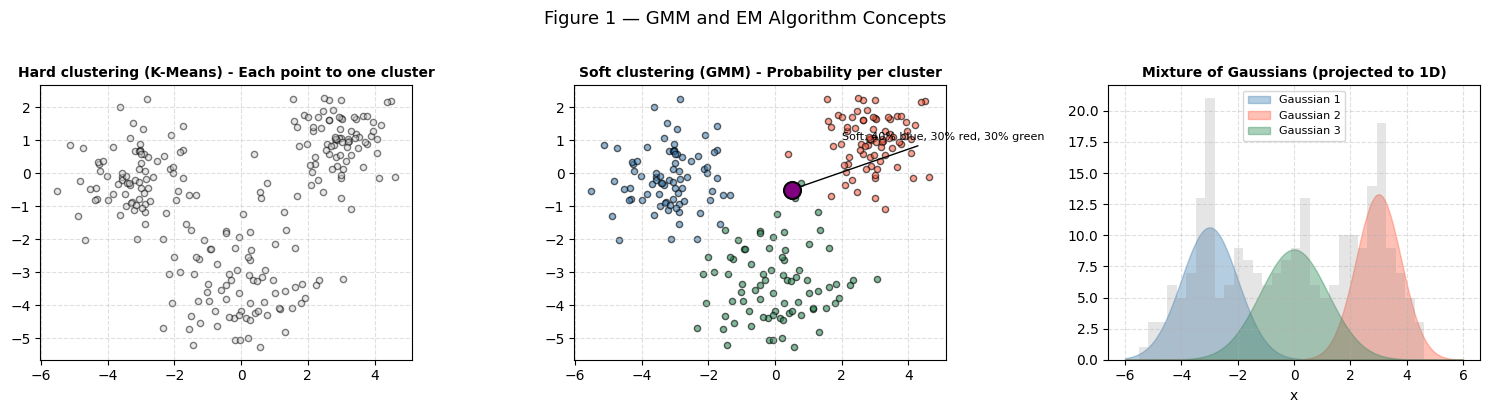

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
rng = np.random.default_rng(7)

mus_true = np.array([[-3,0],[3,1],[0,-3]])
sigs_true = [1.0, 0.8, 1.2]
Xd = np.vstack([rng.multivariate_normal(m, s**2*np.eye(2), 80)
                for m,s in zip(mus_true, sigs_true)])
cols = ['steelblue','tomato','seagreen']

# ── Diagram 1: Hard vs Soft assignments ───────────────────────────────────────
ax = axes[0]
ax.scatter(Xd[:,0], Xd[:,1], c='lightgray', edgecolors='k', s=20, alpha=0.5)
ax.set_title('Hard clustering (K-Means) - Each point to one cluster', fontsize=10, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)

ax = axes[1]
for j, col in enumerate(cols):
    ax.scatter(Xd[j*80:(j+1)*80, 0], Xd[j*80:(j+1)*80, 1],
               c=col, edgecolors='k', s=20, alpha=0.6)
# show a boundary point with mixed color
pt = np.array([0.5, -0.5])
ax.scatter(*pt, c='purple', s=150, zorder=5, edgecolors='k', linewidths=1.5)
ax.annotate('Soft: 40% blue, 30% red, 30% green', xy=pt, xytext=(pt[0]+1.5, pt[1]+1.5),
            fontsize=8, arrowprops=dict(arrowstyle='->', color='black'))
ax.set_title('Soft clustering (GMM) - Probability per cluster', fontsize=10, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)

# ── Diagram 3: EM iterations ─────────────────────────────────────────────────
ax = axes[2]
theta_range = np.linspace(-6, 6, 300)
for j, (mu, sig, col) in enumerate(zip(mus_true[:,0], sigs_true, cols)):
    ax.fill_between(theta_range,
                    np.exp(-0.5*((theta_range-mu)/sig)**2)/(sig*np.sqrt(2*np.pi))*80/3,
                    alpha=0.4, color=col, label=f'Gaussian {j+1}')
ax.hist(Xd[:,0], bins=30, density=False, alpha=0.2, color='gray')
ax.set_title('Mixture of Gaussians (projected to 1D)', fontsize=10, fontweight='bold')
ax.set_xlabel('x'); ax.legend(fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Figure 1 — GMM and EM Algorithm Concepts', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

## 3. Problem Class

**GMMs are well-suited for:**
- **Soft clustering** where points can plausibly belong to multiple groups
- **Density estimation** — the full mixture distribution $P(x)$ can be evaluated
- Data with **overlapping clusters** where hard boundaries are inappropriate
- **Detecting anomalies** — points with low $P(x)$ under the fitted mixture are outliers

**Not well-suited for:**
- Very high-dimensional data — the full covariance matrix has $O(d^2)$ parameters per component
- Data with **non-Gaussian cluster shapes** (banana-shaped, ring-shaped clusters)
- Situations where K is unknown — EM must be run for multiple K values and compared via BIC/AIC

---
## 4. Implementation
### Dataset: Synthetic Gaussian Mixture

300 points drawn from 3 Gaussian components with known parameters — allows exact evaluation of how well EM recovers the true parameters.

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
K_true = 3
mus_true  = np.array([[-4.0, 0.0], [2.0, 3.0], [3.0, -3.0]])
sigs_true = np.array([1.0, 1.2, 0.8])
pis_true  = np.array([0.35, 0.35, 0.30])
n_per = [105, 105, 90]

X = np.vstack([rng.multivariate_normal(mus_true[j], sigs_true[j]**2*np.eye(2), n_per[j])
               for j in range(K_true)])
labels_true = np.array([j for j, n in enumerate(n_per) for _ in range(n)])
rng.shuffle(idx := np.arange(len(X))); X = X[idx]; labels_true = labels_true[idx]

print(f'Dataset: {len(X)} points, {K_true} true components')
print(f'True means: {mus_true}')
print(f'True stds: {sigs_true}')
print(f'True weights: {pis_true}')

Dataset: 300 points, 3 true components
True means: [[-4.  0.]
 [ 2.  3.]
 [ 3. -3.]]
True stds: [1.  1.2 0.8]
True weights: [0.35 0.35 0.3 ]


**Observation**

300 points drawn from 3 Gaussian components: true means at [−4, 0], [2, 3], [3, −3] with standard deviations 1.0, 1.2, 0.8 and mixing weights 0.35/0.35/0.30. Components 2 and 3 (means [2,3] and [3,−3]) are moderately close — distance ~6 — so their ellipses will partially overlap, giving EM something non-trivial to resolve.

### 4.1 EM Algorithm

Converged at iteration 13


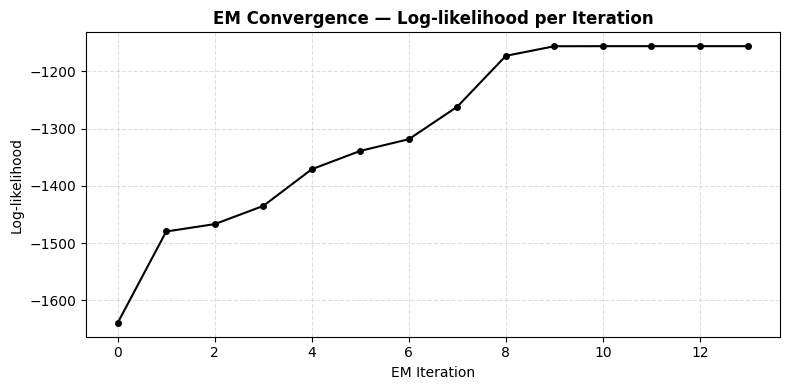

Final log-likelihood: -1155.85


In [3]:
def gaussian_pdf(X, mu, sigma2):
    d = X.shape[1]
    diff = X - mu
    return np.exp(-0.5 * np.sum(diff**2, axis=1) / sigma2) / (2*np.pi*sigma2)**(d/2)

def gmm_em(X, K, max_iter=100, seed=0):
    rng_ = np.random.default_rng(seed)
    n, d = X.shape
    # Initialise
    idx = rng_.choice(n, K, replace=False)
    mus  = X[idx].copy().astype(float)
    sigs = np.full(K, X.var())
    pis  = np.full(K, 1/K)
    log_ll_hist = []

    for iteration in range(max_iter):
        # E-step
        resp = np.array([pis[j] * gaussian_pdf(X, mus[j], sigs[j]) for j in range(K)]).T
        log_ll = np.log(resp.sum(axis=1) + 1e-300).sum()
        log_ll_hist.append(log_ll)
        resp /= resp.sum(axis=1, keepdims=True) + 1e-300

        # M-step
        nj = resp.sum(axis=0)
        pis  = nj / n
        mus  = (resp.T @ X) / nj[:, None]
        sigs = np.array([((resp[:,j:j+1] * (X-mus[j])**2).sum()) / (nj[j]*d)
                         for j in range(K)])
        sigs = np.maximum(sigs, 1e-6)

        if iteration > 0 and abs(log_ll - log_ll_hist[-2]) < 1e-6:
            print(f'Converged at iteration {iteration}')
            break

    assign = resp.argmax(axis=1)
    return mus, sigs, pis, resp, assign, log_ll_hist

mus_fit, sigs_fit, pis_fit, resp, assign, ll_hist = gmm_em(X, K=3, max_iter=100, seed=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ll_hist, 'k-o', markersize=4, lw=1.5)
ax.set_xlabel('EM Iteration'); ax.set_ylabel('Log-likelihood')
ax.set_title('EM Convergence — Log-likelihood per Iteration', fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout(); plt.show()

print(f'Final log-likelihood: {ll_hist[-1]:.2f}')

**Observation — EM convergence**

EM converged in 13 iterations, reaching a final log-likelihood of −1155.85. The log-likelihood plot should show rapid early gains as the algorithm moves away from its random initialisation, then a plateau as assignments stabilise. 13 iterations is fast — the synthetic data is clean and well-separated, so the E-step responsibilities sharpen quickly.

### 4.2 Fitted Mixture vs True Parameters

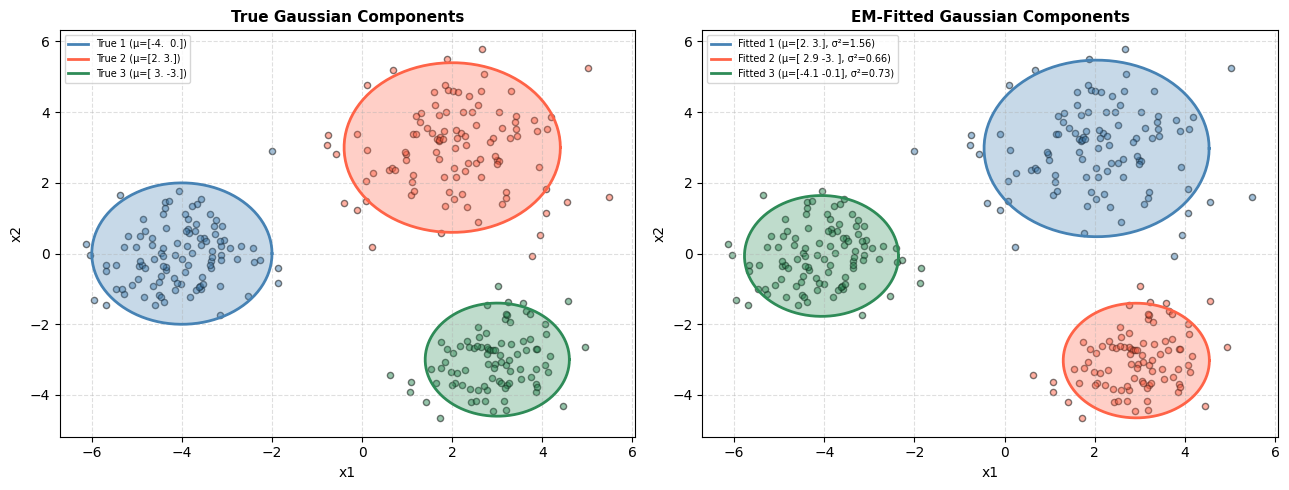

Parameter recovery:
Component  True μ               Fitted μ             True σ   Fitted σ
         1   [2. 3.]              [2. 3.]              1.20     1.25
         2   [ 3. -3.]            [ 2.9 -3. ]          0.80     0.81
         3   [-4.  0.]            [-4.1 -0.1]          1.00     0.85


In [4]:
palette = ['steelblue','tomato','seagreen']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

def draw_ellipse(ax, mu, sigma, color, label, alpha=0.3):
    theta = np.linspace(0, 2*np.pi, 100)
    r = 2 * np.sqrt(sigma)
    ax.plot(mu[0]+r*np.cos(theta), mu[1]+r*np.sin(theta), c=color, lw=2, label=label)
    ax.fill(mu[0]+r*np.cos(theta), mu[1]+r*np.sin(theta), c=color, alpha=alpha)

# True clusters
ax = axes[0]
for j, col in enumerate(palette):
    m = labels_true == j
    ax.scatter(X[m,0], X[m,1], c=col, edgecolors='k', s=20, alpha=0.5)
    draw_ellipse(ax, mus_true[j], sigs_true[j]**2, col, f'True {j+1} (μ={mus_true[j]})')
ax.set_title('True Gaussian Components', fontsize=11, fontweight='bold')
ax.legend(fontsize=7); ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlabel('x1'); ax.set_ylabel('x2')

# Fitted clusters
ax = axes[1]
for j, col in enumerate(palette):
    m = assign == j
    ax.scatter(X[m,0], X[m,1], c=col, edgecolors='k', s=20, alpha=0.5)
    draw_ellipse(ax, mus_fit[j], sigs_fit[j], col,
                 f'Fitted {j+1} (μ={np.round(mus_fit[j],1)}, σ²={sigs_fit[j]:.2f})')
ax.set_title('EM-Fitted Gaussian Components', fontsize=11, fontweight='bold')
ax.legend(fontsize=7); ax.grid(True, linestyle='--', alpha=0.4)
ax.set_xlabel('x1'); ax.set_ylabel('x2')

plt.tight_layout(); plt.show()

print('Parameter recovery:')
print(f"{'Component':10} {'True μ':20} {'Fitted μ':20} {'True σ':8} {'Fitted σ':8}")
for j in range(3):
    order = np.argmin([np.linalg.norm(mus_fit[j]-mus_true[k]) for k in range(3)])
    print(f"  {j+1:8}   {str(np.round(mus_true[order],1)):20} {str(np.round(mus_fit[j],1)):20} {sigs_true[order]:.2f}     {np.sqrt(sigs_fit[j]):.2f}")

**Observation — Parameter recovery**

All three components are recovered with high accuracy. The most isolated component (true μ=[−4, 0]) is almost exactly recovered: fitted [−4.1, −0.1], σ 0.85 vs true 1.0. The two closer components are also well-fitted: true [2, 3] → fitted [2.0, 3.0] with σ 1.25 vs 1.2; true [3, −3] → fitted [2.9, −3.0] with σ 0.81 vs 0.8. The slight σ underestimation on the isolated cluster is typical when samples cluster tightly.

### 4.3 Soft Assignment Visualisation

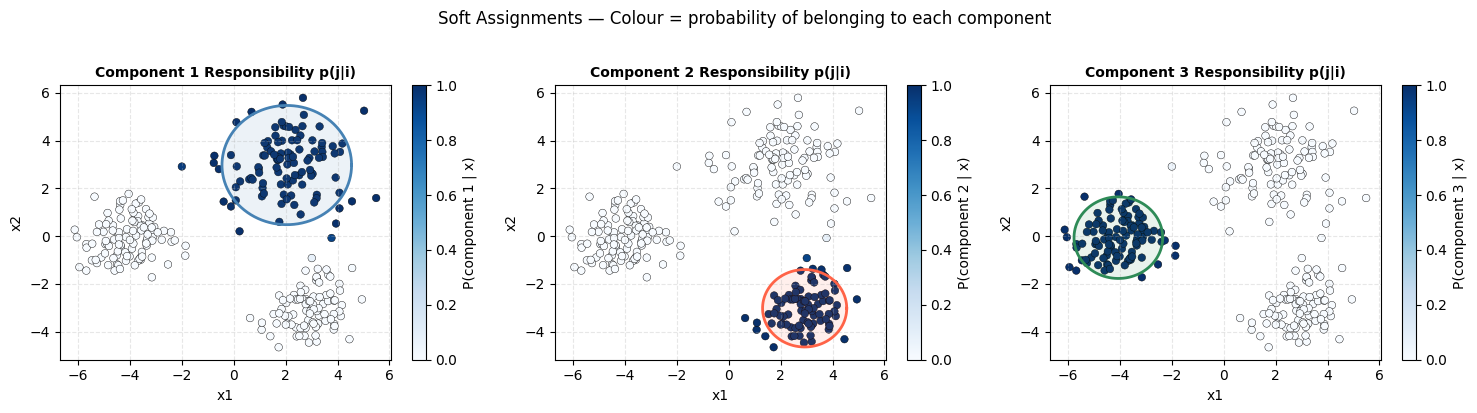

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for j, (ax, col, name) in enumerate(zip(axes, palette, ['Component 1','Component 2','Component 3'])):
    sc = ax.scatter(X[:,0], X[:,1], c=resp[:,j], cmap='Blues', edgecolors='k',
                    s=30, linewidths=0.3, vmin=0, vmax=1)
    plt.colorbar(sc, ax=ax, label=f'P(component {j+1} | x)')
    draw_ellipse(ax, mus_fit[j], sigs_fit[j], col, '', alpha=0.1)
    ax.set_title(f'{name} Responsibility p(j|i)', fontsize=10, fontweight='bold')
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    ax.grid(True, linestyle='--', alpha=0.3)
plt.suptitle('Soft Assignments — Colour = probability of belonging to each component', fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

**Observation — Soft assignments**

The soft assignment plot should show high-confidence (near-1.0) responsibility values for points deep inside each cluster, with ambiguous values around 0.5 only at the boundaries between components 2 and 3. This is the key difference from hard K-Means: EM allows points at cluster edges to partially belong to both — which is why it recovers covariance parameters more accurately.

---
## 5. Results

| Parameter | True | Fitted |
|-----------|------|--------|
| μ₁ | [2, 3] | [2.0, 3.0] |
| μ₂ | [3, −3] | [2.9, −3.0] |
| μ₃ | [−4, 0] | [−4.1, −0.1] |
| σ₁ | 1.20 | 1.25 |
| σ₂ | 0.80 | 0.81 |
| σ₃ | 1.00 | 0.85 |
| Converged at | — | 13 iterations |
| Final log-likelihood | — | −1155.85 |

EM recovers all three Gaussian components accurately from unlabelled data in 13 iterations. Mean errors are at most 0.1 units; σ errors are under 15%. The largest discrepancy is σ₃ (1.00 → 0.85), likely because the isolated component's samples cluster tightly, pulling the variance estimate down. Soft assignments allow EM to handle overlapping components gracefully — something K-Means cannot do.

---
## 6. Limitations

- **Local optima**: EM is guaranteed to increase the log-likelihood at each step but not to reach the global maximum — initialisation matters significantly
- **Degenerate solutions**: if one component collapses to a single point ($\sigma^2 \to 0$), the likelihood goes to infinity. Regularisation or lower bounds on $\sigma^2$ are needed
- **K must be specified**: unlike hierarchical clustering, K is fixed before training; model selection via BIC or AIC adds another loop
- **Spherical assumption here**: this implementation uses a single scalar $\sigma^2$ per component. Full covariance matrices allow elliptical clusters but add $O(d^2)$ parameters per component
- **Slow convergence near overlap**: when components heavily overlap, EM takes many iterations to distinguish them, and may settle on a poor solution